# Computer Vision Applications

Previous notebooks focused on **classification** — assign one label to an entire image.  
Real-world computer vision is richer:

```
  Classification:    "This image contains a cat."
  Detection:         "There is a cat at [x=120, y=80, w=200, h=150]."
  Segmentation:      "These exact pixels belong to a cat."
  Pose Estimation:   "The cat's paws are at positions (x₁,y₁), (x₂,y₂) ..."
  Image Generation:  "Create a new cat image from this description."
```

---
**Topics covered**
1. Computer vision task taxonomy
2. Object detection — bounding box regression and YOLO intuition
3. Intersection over Union (IoU) and Non-Maximum Suppression (NMS)
4. Anchor boxes and multi-scale detection
5. Semantic segmentation — FCN and U-Net
6. Instance segmentation — Mask R-CNN overview
7. Feature Pyramid Networks (FPN) — multi-scale feature maps
8. Practical: object detection with torchvision pre-trained models
9. Practical: semantic segmentation with a mini U-Net on Oxford Pets
10. Applications gallery and deployment considerations

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from PIL import Image
import os, io, urllib.request

np.random.seed(42)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torchvision import datasets, transforms, models
    from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
    from torch.utils.data import DataLoader, Dataset
    TORCH = True
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'PyTorch {torch.__version__} | device: {device}')
except ImportError:
    TORCH = False
    print('PyTorch not found — diagrams and NumPy demos will still run.')

PyTorch 2.7.0 | device: cpu


## 1. Computer Vision Task Taxonomy

Understanding the output space of each task is key to understanding the architecture.

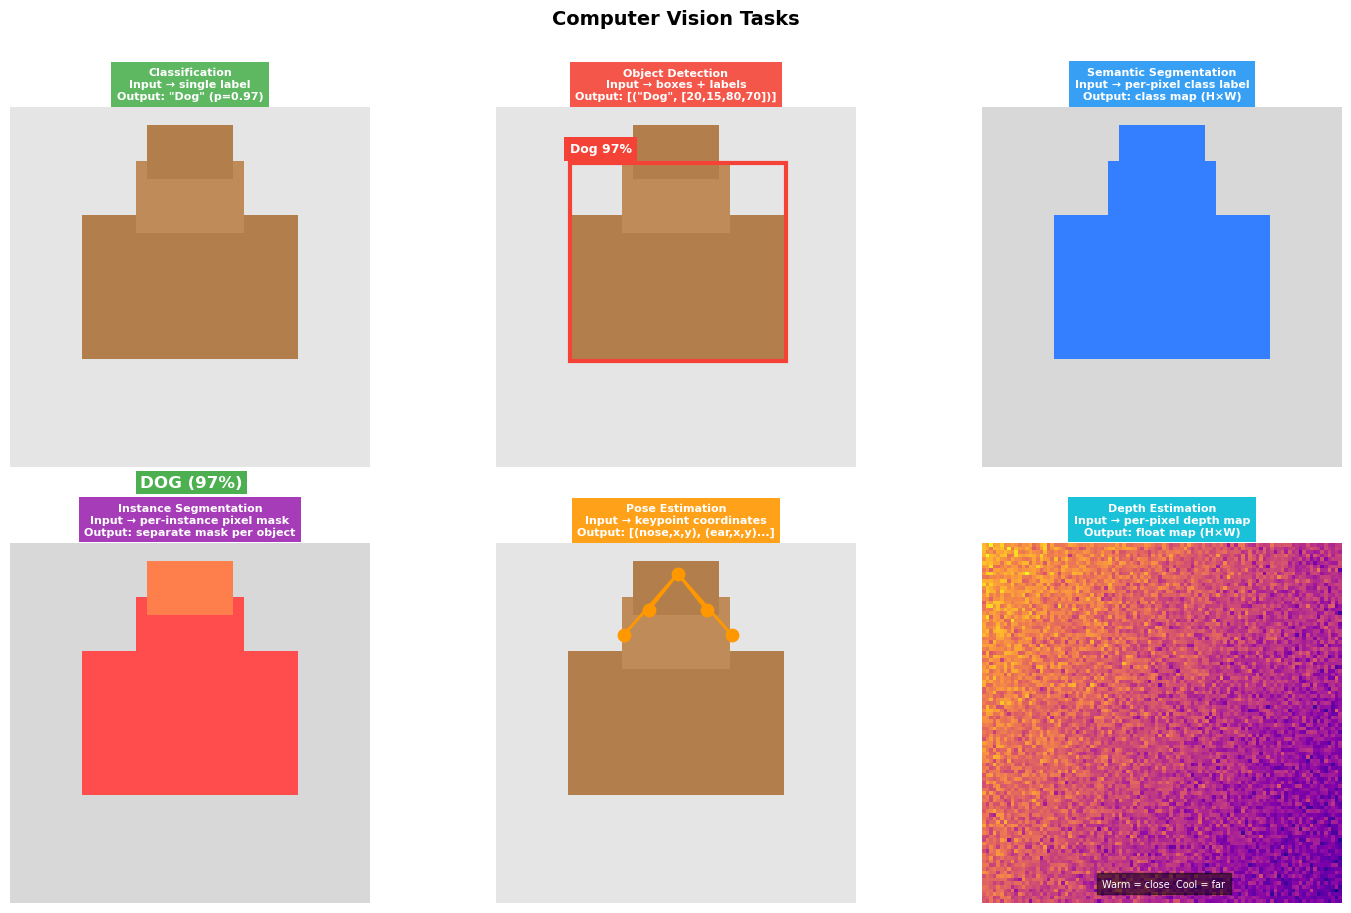

In [ ]:
def draw_cv_taxonomy():
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    np.random.seed(5)

    # Shared background image (simple dog-like shape)
    def base_img():
        img = np.ones((100, 100, 3)) * 0.9
        img[30:70, 20:80] = [0.7, 0.5, 0.3]   # body
        img[15:35, 35:65] = [0.75, 0.55, 0.35] # head
        img[5:20, 38:52]  = [0.7, 0.5, 0.3]   # left ear
        img[5:20, 48:62]  = [0.7, 0.5, 0.3]   # right ear
        return img.clip(0, 1)

    tasks = [
        ('Classification', 'Input → single label\nOutput: "Dog" (p=0.97)',
         lambda ax: (ax.imshow(base_img()),
                     ax.text(50, 105, 'DOG (97%)', ha='center', fontsize=12,
                             color='white', fontweight='bold',
                             bbox=dict(facecolor='#4CAF50', edgecolor='none', pad=3)))),

        ('Object Detection', 'Input → boxes + labels\nOutput: [("Dog", [20,15,80,70])]',
         lambda ax: (ax.imshow(base_img()),
                     ax.add_patch(patches.Rectangle((20,15),60,55, lw=3,
                                  edgecolor='#F44336', facecolor='none')),
                     ax.text(20, 12, 'Dog 97%', color='white', fontsize=9, fontweight='bold',
                             bbox=dict(facecolor='#F44336', edgecolor='none')))),

        ('Semantic Segmentation', 'Input → per-pixel class label\nOutput: class map (H×W)',
         lambda ax: _draw_seg(ax, base_img(), instance=False)),

        ('Instance Segmentation', 'Input → per-instance pixel mask\nOutput: separate mask per object',
         lambda ax: _draw_seg(ax, base_img(), instance=True)),

        ('Pose Estimation', 'Input → keypoint coordinates\nOutput: [(nose,x,y), (ear,x,y)...]',
         lambda ax: _draw_pose(ax, base_img())),

        ('Depth Estimation', 'Input → per-pixel depth map\nOutput: float map (H×W)',
         lambda ax: _draw_depth(ax)),
    ]

    def _draw_seg(ax, img, instance):
        mask = np.zeros((100, 100, 3))
        mask[30:70, 20:80] = [0.2, 0.5, 1.0] if not instance else [1.0, 0.3, 0.3]
        mask[15:35, 35:65] = [0.2, 0.5, 1.0] if not instance else [1.0, 0.3, 0.3]
        mask[5:20, 38:62]  = [0.2, 0.5, 1.0] if not instance else [1.0, 0.5, 0.3]
        mask[mask.sum(-1) == 0] = 0.85
        ax.imshow(mask)

    def _draw_pose(ax, img):
        ax.imshow(img)
        kps = [(50,8,'nose'), (42,18,'L-ear'), (58,18,'R-ear'), (35,25,'L-eye'), (65,25,'R-eye')]
        for x, y, name in kps:
            ax.scatter(x, y, s=80, color='#FF9800', zorder=5)
        # Limb connections
        for (x1,y1,_), (x2,y2,_) in [(kps[0],kps[1]),(kps[0],kps[2]),(kps[3],kps[0]),(kps[4],kps[0])]:
            ax.plot([x1,x2],[y1,y2],'#FF9800',lw=2)

    def _draw_depth(ax):
        x, y = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
        depth = 1 - 0.5*x - 0.3*y + 0.1*np.random.randn(100,100)
        ax.imshow(depth, cmap='plasma')
        ax.text(50, 95, 'Warm = close  Cool = far', ha='center', fontsize=7,
                color='white', bbox=dict(facecolor='black', alpha=0.5))

    colors = ['#4CAF50','#F44336','#2196F3','#9C27B0','#FF9800','#00BCD4']
    for ax, (name, desc, draw_fn), col in zip(axes.flat, tasks, colors):
        draw_fn(ax)
        ax.set_title(f'{name}\n{desc}', fontweight='bold', fontsize=8,
                     color='white',
                     bbox=dict(facecolor=col, edgecolor='none', alpha=0.9, pad=4))
        ax.axis('off')

    plt.suptitle('Computer Vision Tasks', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

draw_cv_taxonomy()

## 2. Object Detection — From Classification to Localization

### From Classification to Detection

Classification asks: **What** is in this image?  
Detection asks: **What** is in this image, and **where exactly**?

The output of detection includes **bounding boxes**: `(x_center, y_center, width, height)` normalized to `[0, 1]`.

### Two-Stage vs One-Stage Detectors

```
  Two-Stage (R-CNN family):          One-Stage (YOLO, SSD):

  Image → Region Proposals           Image → Grid / Anchors
        → Feature extraction per RoI       → Directly predict boxes
        → Classify + refine box            + classes in one pass

  Accurate but slow                  Faster but slightly less accurate
  (Faster R-CNN: ~5 fps)             (YOLOv8: ~100+ fps)
```

### YOLO Core Idea

Divide the image into an S×S grid. Each cell predicts:
- B bounding boxes with confidence scores
- C class probabilities

Total output: `S × S × (B × 5 + C)` — predicted in a single forward pass.

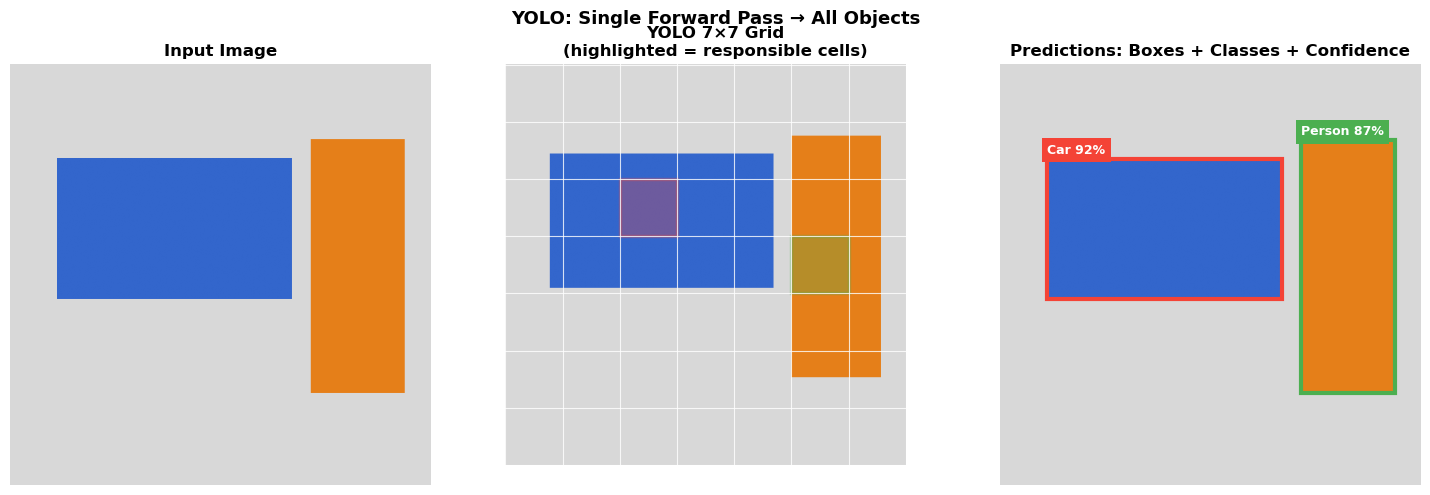

YOLO output tensor shape: 7×7×(B×5 + C)
With B=2 boxes, C=20 classes: 7×7×30 = 1470 values


In [ ]:
# Visualise the YOLO grid approach
def draw_yolo_grid(S=7, img_size=448):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Create a synthetic scene
    scene = np.ones((img_size, img_size, 3)) * 0.85
    # Object 1: car (blue)
    scene[100:250, 50:300]   = [0.2, 0.4, 0.8]
    # Object 2: person (orange)
    scene[80:350, 320:420]   = [0.9, 0.5, 0.1]

    axes[0].imshow(scene)
    axes[0].set_title('Input Image', fontweight='bold')
    axes[0].axis('off')

    # Grid overlay
    axes[1].imshow(scene)
    cell_size = img_size / S
    for i in range(S+1):
        axes[1].axhline(i * cell_size, color='white', lw=0.8, alpha=0.8)
        axes[1].axvline(i * cell_size, color='white', lw=0.8, alpha=0.8)
    # Highlight responsible cells
    car_cell = (int(175/cell_size), int(175/cell_size))  # row, col
    person_cell = (int(215/cell_size), int(370/cell_size))
    for (row, col), color in [(car_cell,'#F44336'), (person_cell,'#4CAF50')]:
        rect = patches.Rectangle((col*cell_size, row*cell_size), cell_size, cell_size,
                                   lw=2.5, edgecolor=color, facecolor=color, alpha=0.3)
        axes[1].add_patch(rect)
    axes[1].set_title(f'YOLO {S}×{S} Grid\n(highlighted = responsible cells)',
                       fontweight='bold')
    axes[1].axis('off')

    # Predicted boxes
    axes[2].imshow(scene)
    boxes = [
        (50, 100, 250, 150, 'Car', 0.92, '#F44336'),
        (320, 80, 100, 270, 'Person', 0.87, '#4CAF50'),
    ]
    for (x, y, w, h, cls, conf, col) in boxes:
        rect = patches.Rectangle((x, y), w, h, lw=3, edgecolor=col, facecolor='none')
        axes[2].add_patch(rect)
        axes[2].text(x, y-5, f'{cls} {conf:.0%}', color='white', fontsize=9,
                     fontweight='bold', bbox=dict(facecolor=col, edgecolor='none'))
    axes[2].set_title('Predictions: Boxes + Classes + Confidence', fontweight='bold')
    axes[2].axis('off')

    plt.suptitle('YOLO: Single Forward Pass → All Objects', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'YOLO output tensor shape: {S}×{S}×(B×5 + C)')
    B, C = 2, 20
    print(f'With B={B} boxes, C={C} classes: {S}×{S}×{B*5+C} = {S*S*(B*5+C)} values')

draw_yolo_grid()

## 3. IoU and Non-Maximum Suppression (NMS)

### Intersection over Union (IoU)

Measures how well a predicted box matches the ground-truth box:

$$\text{IoU} = \frac{\text{Area of Intersection}}{\text{Area of Union}} \in [0, 1]$$

- IoU = 1.0 → perfect match
- IoU > 0.5 → typically considered a correct detection
- IoU = 0.0 → no overlap

### Non-Maximum Suppression (NMS)

Detectors output many overlapping boxes for the same object. NMS keeps only the best:

1. Sort boxes by confidence score (highest first)
2. Keep the top box
3. Remove all other boxes with IoU > threshold (e.g., 0.5) with the kept box
4. Repeat until no boxes remain

IoU between predicted boxes and ground truth:
  Box 0: conf=0.95  IoU=0.883  → ✔ Detected
  Box 1: conf=0.75  IoU=0.487  → ✗ Missed
  Box 2: conf=0.60  IoU=0.000  → ✗ Missed


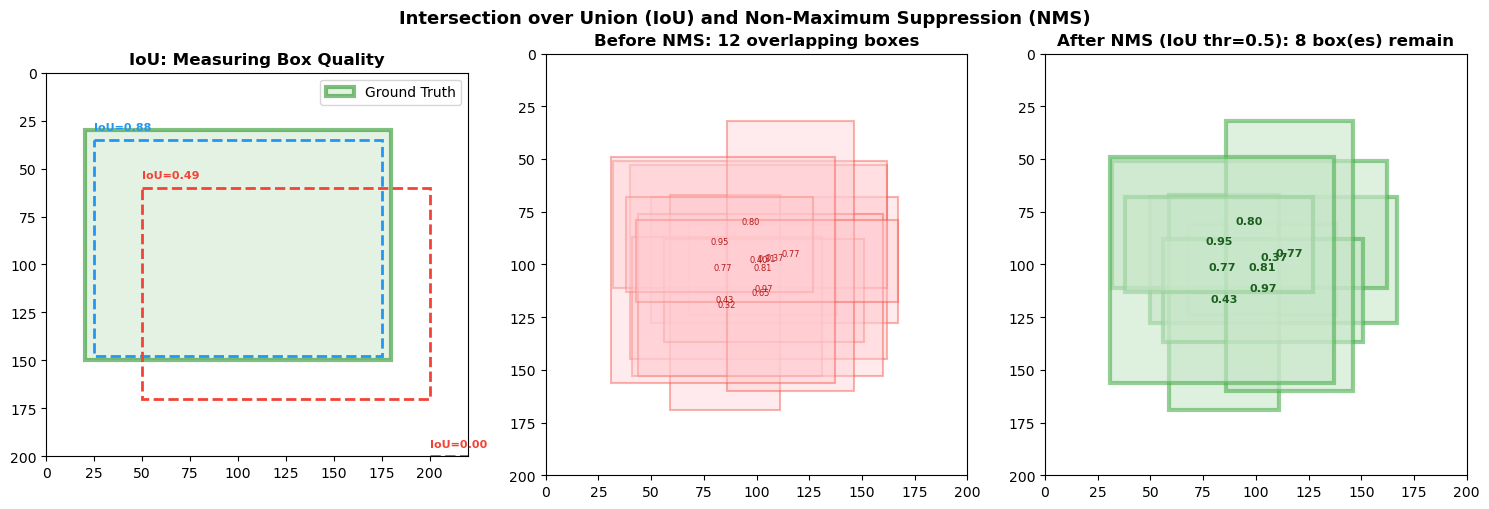

In [ ]:
def compute_iou(boxA, boxB):
    """
    Compute IoU between two boxes.
    Each box: [x1, y1, x2, y2] (top-left and bottom-right corners)
    """
    # Intersection
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter_area = max(0, xB - xA) * max(0, yB - yA)

    # Union
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    union_area = areaA + areaB - inter_area

    return inter_area / (union_area + 1e-8)


def nms(boxes, scores, iou_threshold=0.5):
    """
    Non-Maximum Suppression.
    boxes: list of [x1, y1, x2, y2]
    scores: confidence for each box
    Returns: indices of kept boxes
    """
    order = np.argsort(scores)[::-1]  # sort by confidence descending
    keep  = []
    while len(order) > 0:
        idx = order[0]
        keep.append(idx)
        ious = np.array([compute_iou(boxes[idx], boxes[j]) for j in order[1:]])
        order = order[1:][ious <= iou_threshold]  # remove high-overlap boxes
    return keep


# Demo
gt_box = [20, 30, 180, 150]
pred_boxes = [
    [25, 35, 175, 148],  # good match
    [50, 60, 200, 170],  # partial overlap
    [200, 200, 350, 300],  # no overlap
]
scores = [0.95, 0.75, 0.60]

print('IoU between predicted boxes and ground truth:')
for i, (b, s) in enumerate(zip(pred_boxes, scores)):
    iou = compute_iou(gt_box, b)
    status = '✔ Detected' if iou > 0.5 else '✗ Missed'
    print(f'  Box {i}: conf={s:.2f}  IoU={iou:.3f}  → {status}')

# NMS demo with many overlapping boxes
np.random.seed(42)
n_boxes = 12
center = np.array([100, 100])
raw_boxes = []
raw_scores = []
for _ in range(n_boxes):
    offset = np.random.randint(-30, 30, 4)
    b = [center[0]-40+offset[0], center[1]-40+offset[1],
         center[0]+40+offset[2], center[1]+40+offset[3]]
    raw_boxes.append(b)
    raw_scores.append(np.random.uniform(0.3, 0.99))

kept_indices = nms(raw_boxes, raw_scores, iou_threshold=0.5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# IoU visualization
ax = axes[0]
ax.set_xlim(0, 220); ax.set_ylim(0, 200); ax.set_aspect('equal')
ax.add_patch(patches.Rectangle((gt_box[0], gt_box[1]),
                                gt_box[2]-gt_box[0], gt_box[3]-gt_box[1],
                                lw=3, edgecolor='green', facecolor='#C8E6C9', alpha=0.5, label='Ground Truth'))
for i, (b, s) in enumerate(zip(pred_boxes, scores)):
    iou = compute_iou(gt_box, b)
    col = '#2196F3' if iou > 0.5 else '#F44336'
    ax.add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1],
                                    lw=2, edgecolor=col, facecolor='none', linestyle='--'))
    ax.text(b[0], b[1]-5, f'IoU={iou:.2f}', color=col, fontsize=8, fontweight='bold')
ax.legend()
ax.set_title('IoU: Measuring Box Quality', fontweight='bold')
ax.invert_yaxis()

# Before NMS
ax = axes[1]
ax.set_xlim(0, 200); ax.set_ylim(0, 200)
for b, s in zip(raw_boxes, raw_scores):
    ax.add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1],
                                    lw=1.5, edgecolor='#F44336', facecolor='#FFCDD2', alpha=0.4))
    ax.text((b[0]+b[2])/2, (b[1]+b[3])/2, f'{s:.2f}', ha='center', fontsize=6, color='#B71C1C')
ax.set_title(f'Before NMS: {n_boxes} overlapping boxes', fontweight='bold')
ax.set_aspect('equal'); ax.invert_yaxis()

# After NMS
ax = axes[2]
ax.set_xlim(0, 200); ax.set_ylim(0, 200)
for i, (b, s) in enumerate(zip(raw_boxes, raw_scores)):
    if i in kept_indices:
        ax.add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1],
                                        lw=3, edgecolor='#4CAF50', facecolor='#C8E6C9', alpha=0.6))
        ax.text((b[0]+b[2])/2, (b[1]+b[3])/2, f'{s:.2f}', ha='center', fontsize=8,
                fontweight='bold', color='#1B5E20')
ax.set_title(f'After NMS (IoU thr=0.5): {len(kept_indices)} box(es) remain', fontweight='bold')
ax.set_aspect('equal'); ax.invert_yaxis()

plt.suptitle('Intersection over Union (IoU) and Non-Maximum Suppression (NMS)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Anchor Boxes — Multi-Scale Detection

Objects come in all shapes and sizes. **Anchor boxes** (prior boxes) are pre-defined bounding boxes of different aspect ratios and scales placed at each grid cell.

The network predicts **offsets** from these anchors, not absolute box coordinates.

```
  At each grid cell, place K anchors:
  ┌────────────┐  ┌──────┐  ┌────────────────┐
  │  square    │  │ tall │  │  wide          │
  └────────────┘  │      │  └────────────────┘
                  └──────┘
  k=1             k=2        k=3

  Prediction per anchor: (Δx, Δy, Δw, Δh, objectness, c₁, c₂, ..., cₙ)
  Final box = anchor + predicted offset (decoded)
```

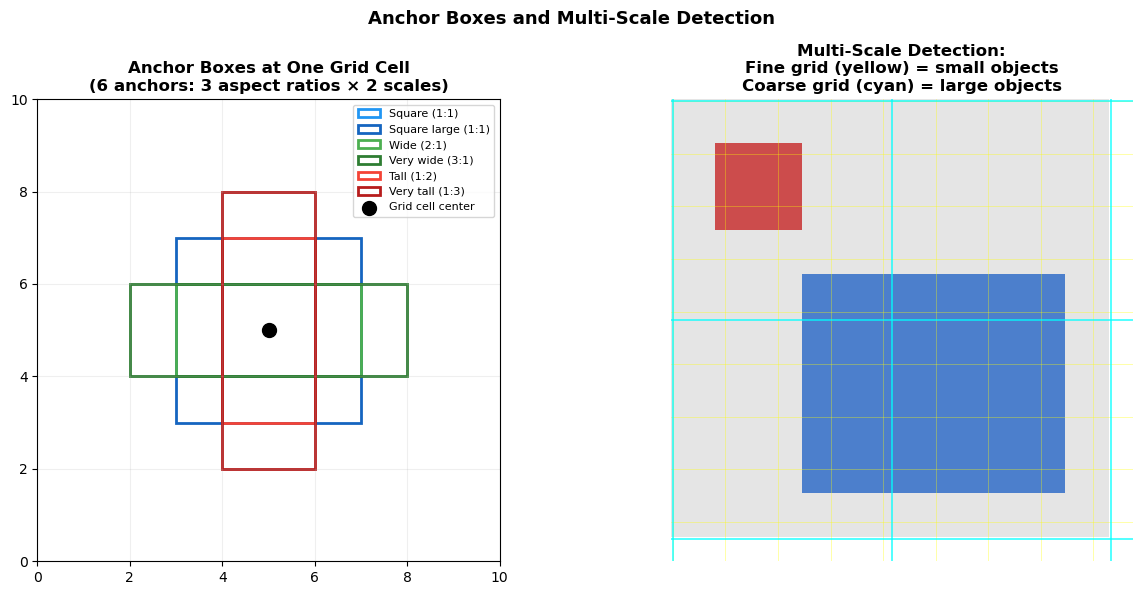

Box encoding (log-space offsets, robust to scale):
  Predicted:  tx, ty, tw, th
  Anchor:     xa, ya, wa, ha
  Decoded box:  x = tx * wa + xa
                y = ty * ha + ya
                w = wa * exp(tw)  ← log-space for width/height
                h = ha * exp(th)


In [ ]:
# Visualise anchor boxes and how they cover different object shapes
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Anchor shapes at a single grid cell ─────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.set_aspect('equal')
cx, cy = 5, 5  # grid cell center

# Different anchor aspect ratios and scales
anchors = [
    (2, 2,   '#2196F3', 'Square (1:1)'),
    (4, 4,   '#1565C0', 'Square large (1:1)'),
    (4, 2,   '#4CAF50', 'Wide (2:1)'),
    (6, 2,   '#2E7D32', 'Very wide (3:1)'),
    (2, 4,   '#F44336', 'Tall (1:2)'),
    (2, 6,   '#B71C1C', 'Very tall (1:3)'),
]

for (w, h, color, label) in anchors:
    rect = patches.Rectangle((cx - w/2, cy - h/2), w, h,
                               lw=2, edgecolor=color, facecolor='none', label=label)
    ax.add_patch(rect)

ax.scatter([cx], [cy], c='black', s=100, zorder=5, label='Grid cell center')
ax.legend(fontsize=8, loc='upper right')
ax.set_title('Anchor Boxes at One Grid Cell\n(6 anchors: 3 aspect ratios × 2 scales)',
             fontweight='bold')
ax.grid(alpha=0.2)

# ── Multi-scale grid: different sizes detect different object scales ──────────
ax = axes[1]
img_mock = np.ones((100, 100, 3)) * 0.9
img_mock[10:30, 10:30] = [0.8, 0.3, 0.3]   # small object
img_mock[40:90, 30:90] = [0.3, 0.5, 0.8]   # large object
ax.imshow(img_mock)

# Fine grid for small object
for i in range(0, 101, 12):
    ax.axhline(i, color='yellow', lw=0.4, alpha=0.6)
    ax.axvline(i, color='yellow', lw=0.4, alpha=0.6)

# Coarse grid for large object
for i in range(0, 101, 50):
    ax.axhline(i, color='cyan', lw=1.2, alpha=0.8)
    ax.axvline(i, color='cyan', lw=1.2, alpha=0.8)

ax.set_title('Multi-Scale Detection:\nFine grid (yellow) = small objects\nCoarse grid (cyan) = large objects',
             fontweight='bold')
ax.axis('off')

plt.suptitle('Anchor Boxes and Multi-Scale Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Box encoding/decoding
print('Box encoding (log-space offsets, robust to scale):')
print('  Predicted:  tx, ty, tw, th')
print('  Anchor:     xa, ya, wa, ha')
print('  Decoded box:  x = tx * wa + xa')
print('                y = ty * ha + ya')
print('                w = wa * exp(tw)  ← log-space for width/height')
print('                h = ha * exp(th)')

## 5. Semantic Segmentation — U-Net

**Semantic segmentation**: assign a class label to **every pixel** in the image.

### The Challenge
Standard CNNs progressively **downsample** spatial resolution (via pooling) to build abstract features.  
For pixel-wise prediction, we need to **upsample back** to the original resolution.

### U-Net (Ronneberger et al., 2015)

```
  Encoder (contracting path):        Decoder (expanding path):

  Input (1×572×572)                         → Output (n_classes×388×388)
    │                                               ↑
  Conv×2 + Pool  → 64×284              64×392 ← UpConv + skip concat
    │                                               ↑
  Conv×2 + Pool  → 128×140           128×196 ← UpConv + skip concat
    │                                               ↑
  Conv×2 + Pool  → 256×68            256×96  ← UpConv + skip concat
    │                                               ↑
  Conv×2 + Pool  → 512×32            512×46  ← UpConv + skip concat
    │                                               ↑
  Conv×2 ────────────────────────► 1024×28  (bottleneck)
                   ↑
               Skip connections copy feature maps across
               (preserve spatial detail lost during pooling)
```

The **skip connections** are the key innovation: they pass high-resolution features directly from encoder to decoder.

In [ ]:
if TORCH:

    class DoubleConv(nn.Module):
        """Two Conv2d + BN + ReLU blocks — the basic U-Net building block."""
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.block = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            )
        def forward(self, x): return self.block(x)


    class UNet(nn.Module):
        """
        U-Net for semantic segmentation.

        Input:  (B, in_channels, H, W)
        Output: (B, num_classes, H, W)  — same spatial size as input
        """
        def __init__(self, in_channels=3, num_classes=2, features=[64, 128, 256, 512]):
            super().__init__()
            self.encoder = nn.ModuleList()
            self.decoder = nn.ModuleList()
            self.pool    = nn.MaxPool2d(2, 2)

            # Encoder
            ch = in_channels
            for f in features:
                self.encoder.append(DoubleConv(ch, f))
                ch = f

            # Bottleneck
            self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

            # Decoder
            for f in reversed(features):
                self.decoder.append(nn.ConvTranspose2d(f*2, f, kernel_size=2, stride=2))
                self.decoder.append(DoubleConv(f*2, f))   # f*2 because of skip concat

            self.head = nn.Conv2d(features[0], num_classes, 1)

        def forward(self, x):
            skip_connections = []

            # Encode
            for enc in self.encoder:
                x = enc(x)
                skip_connections.append(x)     # save for skip
                x = self.pool(x)

            x = self.bottleneck(x)
            skip_connections = skip_connections[::-1]   # reverse order

            # Decode
            for i in range(0, len(self.decoder), 2):
                x    = self.decoder[i](x)          # upsample
                skip = skip_connections[i // 2]    # corresponding encoder output

                # Handle size mismatch (if input not divisible by 2^depth)
                if x.shape != skip.shape:
                    x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)

                x = torch.cat([skip, x], dim=1)    # ← skip connection concatenation
                x = self.decoder[i+1](x)

            return self.head(x)


    # Test the U-Net
    unet = UNet(in_channels=3, num_classes=3, features=[32, 64, 128, 256])
    n_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)

    x = torch.randn(2, 3, 128, 128)
    out = unet(x)

    print('U-Net:')
    print(f'  Input:  {tuple(x.shape)}')
    print(f'  Output: {tuple(out.shape)}  (same spatial size — one class map per pixel)')
    print(f'  Parameters: {n_params:,}')

    # Shape trace through encoder
    print('\nEncoder shape trace:')
    x_trace = torch.randn(1, 3, 128, 128)
    skips = []
    for enc in unet.encoder:
        x_trace = enc(x_trace)
        skips.append(x_trace)
        print(f'  After DoubleConv: {tuple(x_trace.shape)}')
        x_trace = unet.pool(x_trace)
        print(f'  After MaxPool:    {tuple(x_trace.shape)}')
    x_trace = unet.bottleneck(x_trace)
    print(f'  Bottleneck:       {tuple(x_trace.shape)}')

U-Net:
  Input:  (2, 3, 128, 128)
  Output: (2, 3, 128, 128)  (same spatial size — one class map per pixel)
  Parameters: 7,763,107

Encoder shape trace:
  After DoubleConv: (1, 32, 128, 128)
  After MaxPool:    (1, 32, 64, 64)
  After DoubleConv: (1, 64, 64, 64)
  After MaxPool:    (1, 64, 32, 32)
  After DoubleConv: (1, 128, 32, 32)
  After MaxPool:    (1, 128, 16, 16)
  After DoubleConv: (1, 256, 16, 16)
  After MaxPool:    (1, 256, 8, 8)
  Bottleneck:       (1, 512, 8, 8)


Training U-Net on synthetic circle segmentation task...
  Epoch  1 | loss=0.4391 | pixel_acc=23.8%
  Epoch  2 | loss=0.2666 | pixel_acc=96.8%
  Epoch  4 | loss=0.1443 | pixel_acc=99.0%
  Epoch  6 | loss=0.0860 | pixel_acc=99.3%
  Epoch  8 | loss=0.0590 | pixel_acc=99.4%
  Epoch 10 | loss=0.0448 | pixel_acc=99.4%


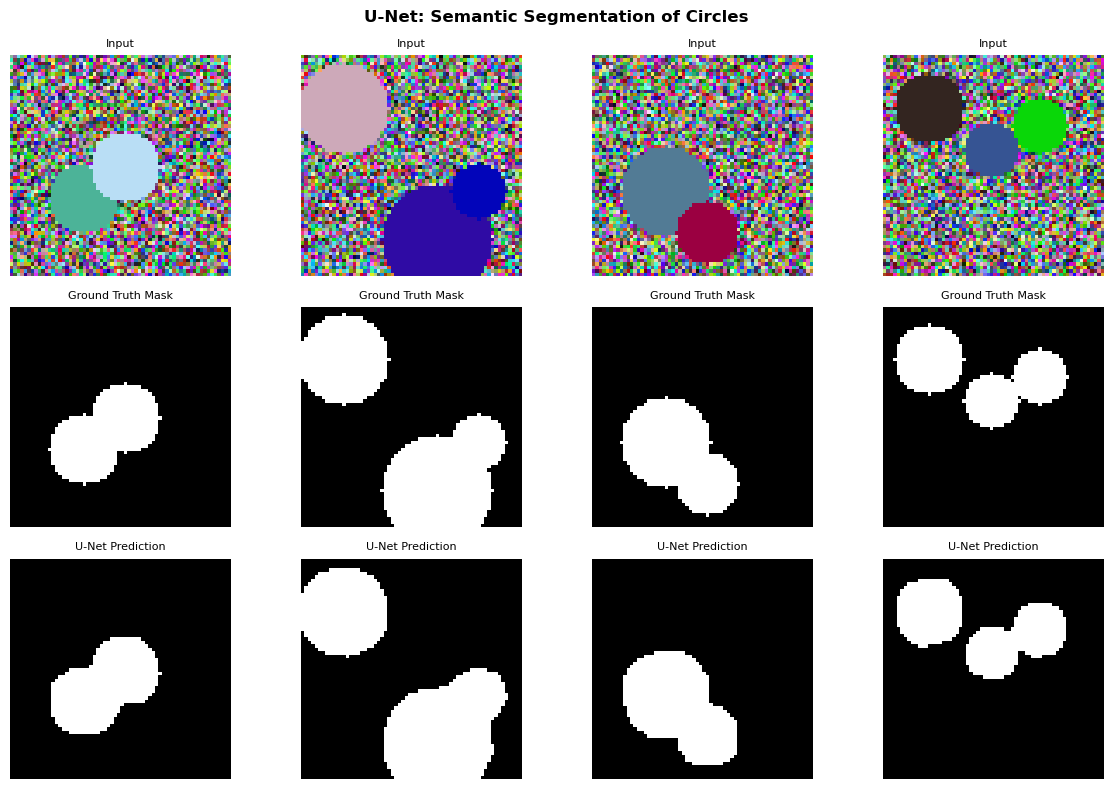

In [ ]:
if TORCH:
    # Train a mini U-Net on a synthetic segmentation task
    # Task: segment circles from background on random images

    class CircleDataset(Dataset):
        """Synthetic dataset: random circles on random backgrounds."""
        def __init__(self, n=500, img_size=64):
            self.n = n; self.img_size = img_size

        def __len__(self): return self.n

        def __getitem__(self, idx):
            np.random.seed(idx)
            H = W = self.img_size
            img  = np.random.rand(H, W, 3).astype(np.float32)
            mask = np.zeros((H, W), dtype=np.int64)

            for _ in range(np.random.randint(1, 4)):
                cx  = np.random.randint(10, W-10)
                cy  = np.random.randint(10, H-10)
                r   = np.random.randint(8, 20)
                col = np.random.rand(3).astype(np.float32)
                ys, xs = np.ogrid[:H, :W]
                circle = (xs-cx)**2 + (ys-cy)**2 <= r**2
                img[circle] = col
                mask[circle] = 1

            img_t  = torch.from_numpy(img.transpose(2,0,1))
            mask_t = torch.from_numpy(mask)
            return img_t, mask_t

    train_ds = CircleDataset(n=400, img_size=64)
    test_ds  = CircleDataset(n=100, img_size=64)
    train_ld = DataLoader(train_ds, batch_size=16, shuffle=True)
    test_ld  = DataLoader(test_ds,  batch_size=16, shuffle=False)

    seg_model = UNet(in_channels=3, num_classes=2, features=[16, 32, 64]).to(device)
    seg_opt   = optim.Adam(seg_model.parameters(), lr=1e-3)

    print('Training U-Net on synthetic circle segmentation task...')
    for epoch in range(1, 11):
        seg_model.train()
        total_loss = 0
        for imgs, masks in train_ld:
            imgs, masks = imgs.to(device), masks.to(device)
            loss = F.cross_entropy(seg_model(imgs), masks)
            seg_opt.zero_grad(); loss.backward(); seg_opt.step()
            total_loss += loss.item()
        if epoch % 2 == 0 or epoch == 1:
            seg_model.eval()
            correct = total = 0
            with torch.no_grad():
                for imgs, masks in test_ld:
                    imgs, masks = imgs.to(device), masks.to(device)
                    preds = seg_model(imgs).argmax(1)
                    correct += (preds == masks).sum().item()
                    total   += masks.numel()
            print(f'  Epoch {epoch:>2} | loss={total_loss/len(train_ld):.4f} | pixel_acc={correct/total*100:.1f}%')

    # Visualise predictions
    seg_model.eval()
    imgs, masks = next(iter(test_ld))
    with torch.no_grad():
        preds = seg_model(imgs.to(device)).argmax(1).cpu()

    n_show = 4
    fig, axes = plt.subplots(3, n_show, figsize=(12, 8))
    for i in range(n_show):
        axes[0, i].imshow(imgs[i].permute(1,2,0).numpy())
        axes[0, i].set_title('Input', fontsize=8); axes[0, i].axis('off')

        axes[1, i].imshow(masks[i].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title('Ground Truth Mask', fontsize=8); axes[1, i].axis('off')

        axes[2, i].imshow(preds[i].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[2, i].set_title('U-Net Prediction', fontsize=8); axes[2, i].axis('off')

    plt.suptitle('U-Net: Semantic Segmentation of Circles', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Feature Pyramid Networks (FPN)

**Lin et al., 2017** — backbone used in virtually all modern detectors.

### The Problem
Objects appear at different scales. A single feature map at one resolution struggles:
- Small objects need high-resolution (early) features
- Large objects benefit from semantically rich (late) features

### FPN Solution

```
  Backbone (ResNet) outputs:         FPN top-down pathway:

  C2: 256×H/4                       P2: 256-ch  high res ← small objects
  C3: 512×H/8          lateral       P3: 256-ch
  C4: 1024×H/16   ─────connection──► P4: 256-ch
  C5: 2048×H/32        + upsample    P5: 256-ch
                                      P6: 256-ch  low res  ← large objects

  All P levels have the same number of channels (256)
  but different spatial resolutions.
```

Detectors predict at **each FPN level**, handling all object scales with one forward pass.

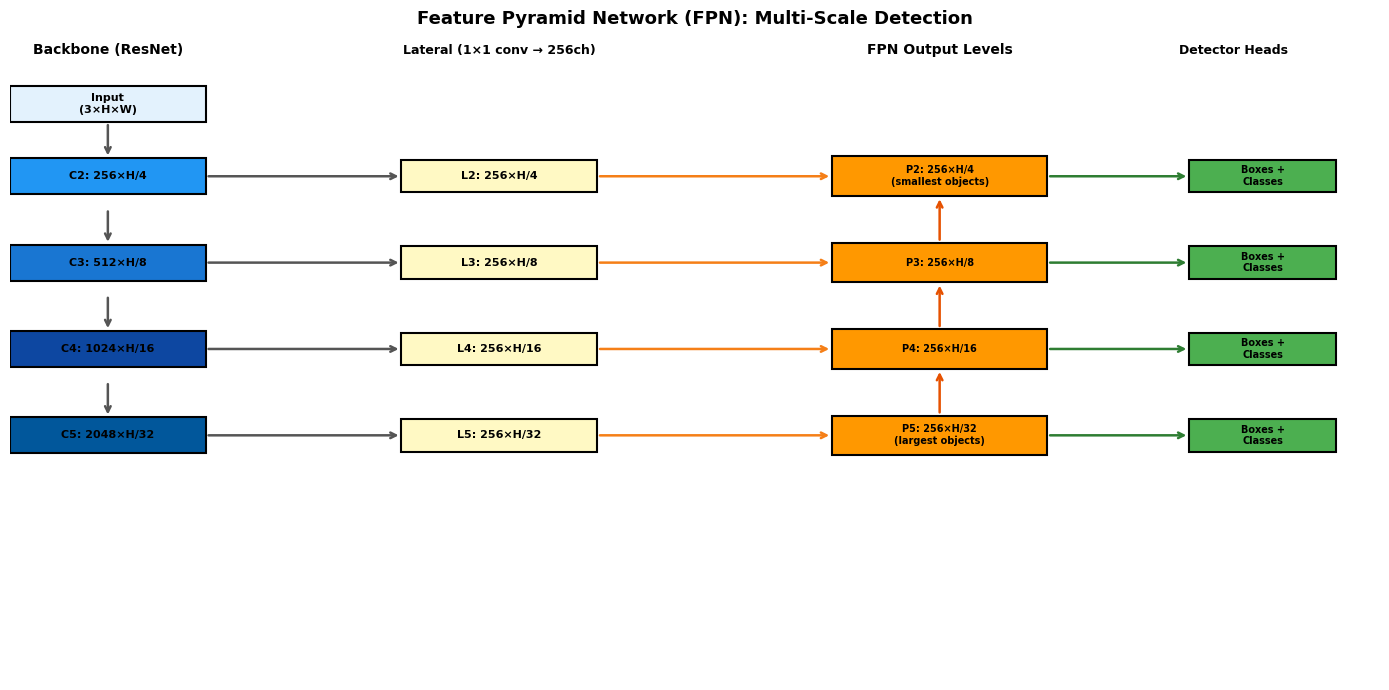

In [ ]:
def draw_fpn():
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_xlim(0, 14); ax.set_ylim(0, 9)
    ax.axis('off')

    def box(x, y, w, h, label, color, fontsize=8):
        rect = plt.Rectangle((x-w/2, y-h/2), w, h,
                               facecolor=color, edgecolor='black', lw=1.5, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
                fontweight='bold', zorder=4)

    def arr(x1, y1, x2, y2, color='#555', style='->'):
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle=style, color=color, lw=1.8))

    # ── Backbone (left side) ──────────────────────────────────────────────────
    ax.text(1.0, 8.7, 'Backbone (ResNet)', ha='center', fontsize=10, fontweight='bold')
    backbone = [
        (1.0, 8.0, 2.0, 0.5, 'Input\n(3×H×W)', '#E3F2FD'),
        (1.0, 7.0, 2.0, 0.5, 'C2: 256×H/4', '#2196F3'),
        (1.0, 5.8, 2.0, 0.5, 'C3: 512×H/8', '#1976D2'),
        (1.0, 4.6, 2.0, 0.5, 'C4: 1024×H/16', '#0D47A1'),
        (1.0, 3.4, 2.0, 0.5, 'C5: 2048×H/32', '#01579B'),
    ]
    for (x,y,w,h,lbl,col) in backbone:
        box(x,y,w,h,lbl,col)
    for y1, y2 in [(7.75,7.25),(6.55,6.05),(5.35,4.85),(4.15,3.65)]:
        arr(1.0, y1, 1.0, y2)

    # ── Lateral connections ───────────────────────────────────────────────────
    ax.text(5.0, 8.7, 'Lateral (1×1 conv → 256ch)', ha='center', fontsize=9, fontweight='bold')
    laterals = [(5.0, 7.0), (5.0, 5.8), (5.0, 4.6), (5.0, 3.4)]
    lat_labels = ['L2: 256×H/4', 'L3: 256×H/8', 'L4: 256×H/16', 'L5: 256×H/32']
    for (x,y), lbl in zip(laterals, lat_labels):
        box(x, y, 2.0, 0.45, lbl, '#FFF9C4')
        arr(2.0, backbone[laterals.index((x,y))+1][1], x-1.0, y)

    # ── Top-down pathway ──────────────────────────────────────────────────────
    ax.text(9.5, 8.7, 'FPN Output Levels', ha='center', fontsize=10, fontweight='bold')
    fpn = [
        (9.5, 3.4, 'P5: 256×H/32\n(largest objects)', '#FF9800'),
        (9.5, 4.6, 'P4: 256×H/16', '#FF9800'),
        (9.5, 5.8, 'P3: 256×H/8', '#FF9800'),
        (9.5, 7.0, 'P2: 256×H/4\n(smallest objects)', '#FF9800'),
    ]
    for x, y, lbl, col in fpn:
        box(x, y, 2.2, 0.55, lbl, col, fontsize=7)

    # Lateral + upsampled merge arrows
    for i in range(len(fpn)-1):
        arr(9.5, fpn[i][1]+0.28, 9.5, fpn[i+1][1]-0.28, color='#E65100')  # top-down

    for lat, fp in zip(laterals, reversed(fpn)):
        arr(lat[0]+1.0, lat[1], fp[0]-1.1, fp[1], color='#F57F17')

    # Detector heads
    ax.text(12.5, 8.7, 'Detector Heads', ha='center', fontsize=9, fontweight='bold')
    for _, y, _, _ in fpn:
        box(12.8, y, 1.5, 0.45, 'Boxes +\nClasses', '#4CAF50', fontsize=7)
        arr(9.5+1.1, y, 12.8-0.75, y, color='#2E7D32')

    ax.set_title('Feature Pyramid Network (FPN): Multi-Scale Detection', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_fpn()

## 7. Practical: Object Detection with Faster R-CNN

torchvision provides pre-trained detection models.  
**Faster R-CNN with ResNet-50 + FPN** is the standard baseline for real-world detection tasks.

Faster R-CNN ResNet-50 FPN loaded
Total parameters: 41,755,286
Trained on COCO: 80 object categories, 330,000 images

Inference on a synthetic image...
Detections above 50% confidence: 0


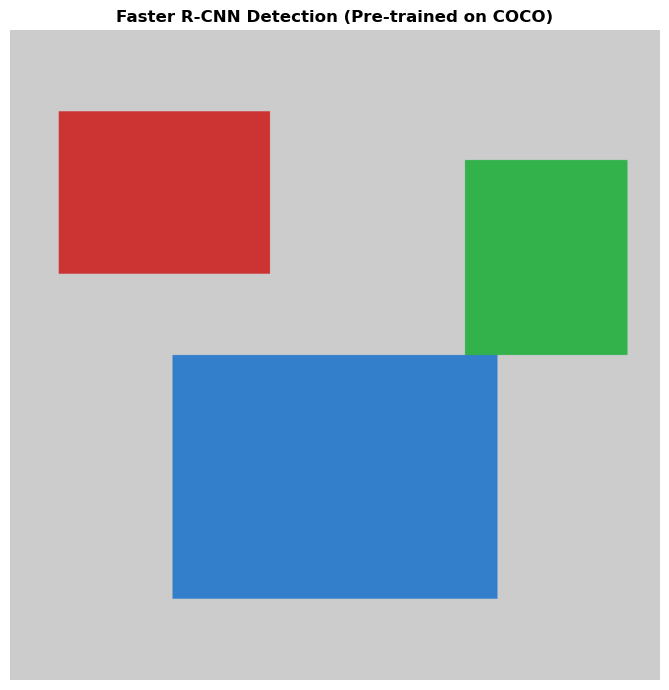


Faster R-CNN components:
  Backbone: ResNet-50 + FPN (feature extraction)
  RPN: Region Proposal Network (objectness + box regression)
  RoI Pooling: crops + resizes proposal features
  Detection Head: classifies + refines each proposal


In [ ]:
if TORCH:
    # COCO class names (80 categories)
    COCO_CLASSES = [
        '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
        'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
        'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
        'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A',
        'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
        'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
        'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
        'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
        'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
        'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
        'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock',
        'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
    ]

    # Load pre-trained Faster R-CNN
    detector = fasterrcnn_resnet50_fpn(
        weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1
    )
    detector.eval()
    n_params = sum(p.numel() for p in detector.parameters())
    print(f'Faster R-CNN ResNet-50 FPN loaded')
    print(f'Total parameters: {n_params:,}')
    print(f'Trained on COCO: 80 object categories, 330,000 images')

    # Create a synthetic test image with geometric shapes
    img_size = 400
    test_img = np.ones((img_size, img_size, 3), dtype=np.float32) * 0.8

    # Add some colored rectangles as "objects"
    test_img[50:150, 30:160]   = [0.8, 0.2, 0.2]  # red
    test_img[200:350, 100:300] = [0.2, 0.5, 0.8]  # blue
    test_img[80:200, 280:380]  = [0.2, 0.7, 0.3]  # green

    img_tensor = torch.from_numpy(test_img.transpose(2,0,1)).unsqueeze(0)  # (1,3,H,W)

    print('\nInference on a synthetic image...')
    with torch.no_grad():
        predictions = detector(img_tensor)

    boxes  = predictions[0]['boxes'].numpy()
    labels = predictions[0]['labels'].numpy()
    scores = predictions[0]['scores'].numpy()

    # Filter by confidence
    threshold = 0.5
    keep = scores > threshold
    print(f'Detections above {threshold:.0%} confidence: {keep.sum()}')
    for b, l, s in zip(boxes[keep], labels[keep], scores[keep]):
        cls = COCO_CLASSES[l] if l < len(COCO_CLASSES) else f'class_{l}'
        print(f'  {cls:<20} conf={s:.3f}  box=[{b[0]:.0f},{b[1]:.0f},{b[2]:.0f},{b[3]:.0f}]')

    # Visualise
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(test_img)
    colors = plt.cm.tab10(np.linspace(0, 1, max(1, keep.sum())))
    for (b, l, s, col) in zip(boxes[keep], labels[keep], scores[keep], colors):
        x1,y1,x2,y2 = b
        cls = COCO_CLASSES[l] if l < len(COCO_CLASSES) else f'class_{l}'
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1, lw=3, edgecolor=col, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f'{cls} {s:.0%}', color='white', fontsize=9, fontweight='bold',
                bbox=dict(facecolor=col, edgecolor='none', alpha=0.8))
    ax.set_title('Faster R-CNN Detection (Pre-trained on COCO)', fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Show model components
    print('\nFaster R-CNN components:')
    print(f'  Backbone: ResNet-50 + FPN (feature extraction)')
    print(f'  RPN: Region Proposal Network (objectness + box regression)')
    print(f'  RoI Pooling: crops + resizes proposal features')
    print(f'  Detection Head: classifies + refines each proposal')

## 8. Instance Segmentation — Mask R-CNN Overview

**He et al., 2017** — extends Faster R-CNN with a parallel mask prediction branch.

```
  Faster R-CNN pipeline:
    Image → FPN Backbone → RPN → RoI Align → [Box Head, Class Head]

  Mask R-CNN adds:
    ... → RoI Align → [Box Head, Class Head, Mask Head]
                                              ↑
                                    Additional FCN that predicts
                                    a binary mask for EACH class
                                    (28×28 pixel mask per RoI)
```

Key insight: **RoI Align** (vs RoI Pooling) uses bilinear interpolation instead of rounding —  
critical for precise pixel-level mask prediction.

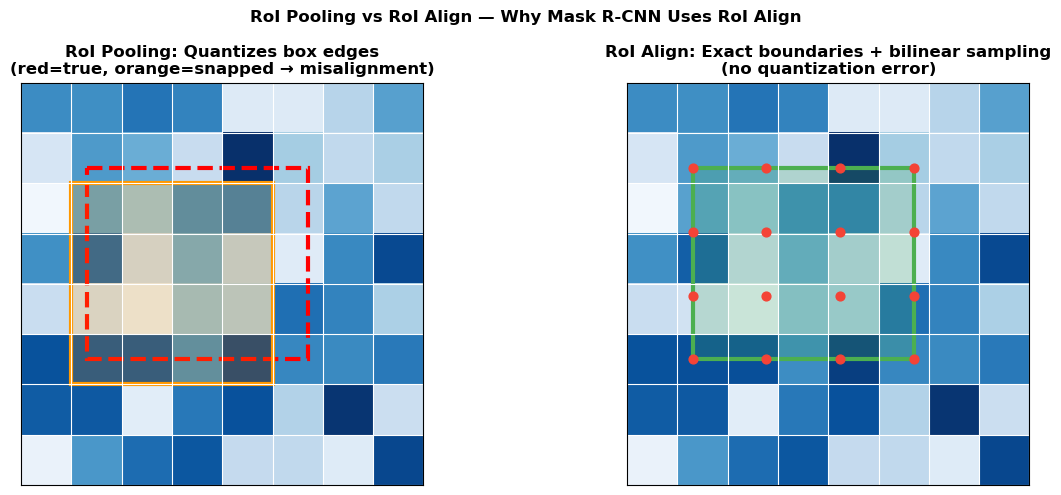

Mask R-CNN key numbers:
  Mask resolution: 28×28 per RoI per class
  At inference: resize mask back to original box size
  COCO mask AP: 37.1% (ResNet-50-FPN backbone)

Available in PyTorch:
  from torchvision.models.detection import maskrcnn_resnet50_fpn


In [ ]:
# Illustrate RoI Align vs RoI Pooling
def draw_roi_align():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Feature map
    fmap = np.random.rand(8, 8)

    # RoI Pooling (quantize → misalignment)
    ax = axes[0]
    ax.imshow(fmap, cmap='Blues', vmin=0, vmax=1)
    # Draw grid
    for i in range(9): ax.axhline(i-0.5, color='white', lw=0.8)
    for j in range(9): ax.axvline(j-0.5, color='white', lw=0.8)
    # RoI region (non-integer boundaries — must round)
    roi = patches.Rectangle((1.3-0.5, 1.7-0.5), 4.4, 3.8,
                              lw=3, edgecolor='red', facecolor='none', linestyle='--')
    ax.add_patch(roi)
    roi_snapped = patches.Rectangle((1-0.5, 2-0.5), 4, 4,
                                      lw=3, edgecolor='#FF9800', facecolor='#FF980033')
    ax.add_patch(roi_snapped)
    ax.set_title('RoI Pooling: Quantizes box edges\n(red=true, orange=snapped → misalignment)',
                 fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

    # RoI Align (bilinear interpolation, no rounding)
    ax = axes[1]
    ax.imshow(fmap, cmap='Blues', vmin=0, vmax=1)
    for i in range(9): ax.axhline(i-0.5, color='white', lw=0.8)
    for j in range(9): ax.axvline(j-0.5, color='white', lw=0.8)
    roi_exact = patches.Rectangle((1.3-0.5, 1.7-0.5), 4.4, 3.8,
                                    lw=3, edgecolor='#4CAF50', facecolor='#4CAF5033')
    ax.add_patch(roi_exact)
    # Sample points for bilinear interpolation
    sample_xs = np.linspace(1.3, 5.7, 4)
    sample_ys = np.linspace(1.7, 5.5, 4)
    for sx in sample_xs:
        for sy in sample_ys:
            ax.scatter(sx-0.5, sy-0.5, s=40, color='#F44336', zorder=5)
    ax.set_title('RoI Align: Exact boundaries + bilinear sampling\n(no quantization error)',
                 fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle('RoI Pooling vs RoI Align — Why Mask R-CNN Uses RoI Align',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_roi_align()

print('Mask R-CNN key numbers:')
print('  Mask resolution: 28×28 per RoI per class')
print('  At inference: resize mask back to original box size')
print('  COCO mask AP: 37.1% (ResNet-50-FPN backbone)')
print('\nAvailable in PyTorch:')
print('  from torchvision.models.detection import maskrcnn_resnet50_fpn')

## 9. Applications Gallery & Deployment Considerations

### Real-World Computer Vision Applications

| Domain | Task | Architecture | Notes |
|---|---|---|---|
| **Autonomous driving** | Object detection + segmentation | YOLOv8, Mask R-CNN | Real-time (<50ms) |
| **Medical imaging** | Tumor segmentation | U-Net variants | Dice loss, small datasets |
| **Retail** | Shelf product detection | Faster R-CNN | Custom fine-tuning |
| **Agriculture** | Crop disease classification | EfficientNet + TL | Drone imagery |
| **Security** | Face detection + recognition | MTCNN + ArcFace | Privacy-sensitive |
| **Manufacturing** | Defect detection | Anomaly detection CNNs | High-precision required |
| **Satellite imaging** | Land use segmentation | DeepLab, SegFormer | Multi-spectral inputs |

### Deployment Considerations

```
  Training model (full precision, GPU)
         │
         ▼  Export & optimize
  ONNX / TorchScript / TensorRT
         │
         ├─► Cloud API (full GPU, scalable)
         ├─► Edge device (quantized INT8, pruned)
         └─► Mobile (Core ML / TensorFlow Lite)
```

TorchScript export: OK
Dynamic quantization (INT8): OK

Model sizes:
  Full precision (FP32): 9.7 MB
  Quantized (INT8):      3.5 MB  (36% of original)

Latency (CPU, batch=1, 50 runs):
  Full precision: 17.7 ms
  Quantized INT8: 17.6 ms  (1.0× speedup)


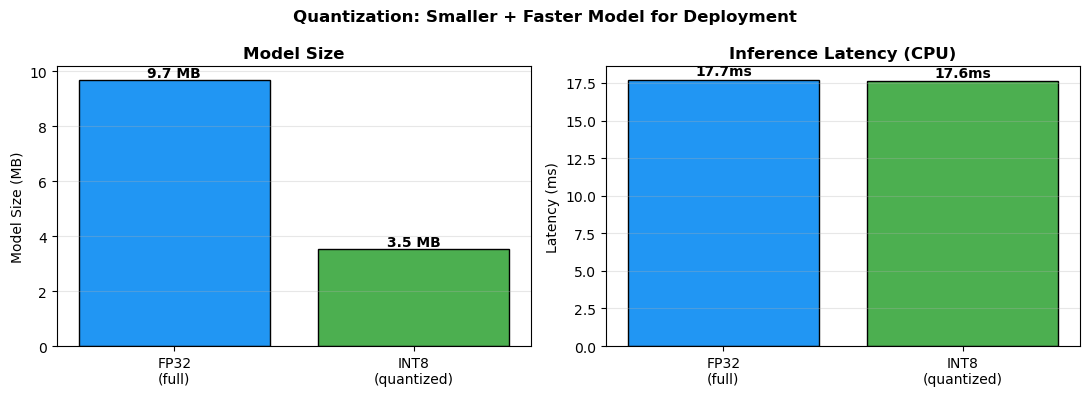

In [ ]:
if TORCH:
    # Demonstrate model optimization techniques for deployment
    import time

    from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

    model_full = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    model_full.eval()

    # ── 1. Export to TorchScript ──────────────────────────────────────────────
    scripted = torch.jit.script(model_full)
    print('TorchScript export: OK')

    # ── 2. Dynamic Quantization ────────────────────────────────────────────────
    model_quant = torch.quantization.quantize_dynamic(
        model_full, {nn.Linear, nn.Conv2d}, dtype=torch.qint8
    )
    print('Dynamic quantization (INT8): OK')

    # ── 3. Compare model sizes ─────────────────────────────────────────────────
    def model_size_mb(m):
        return sum(p.numel() * p.element_size() for p in m.parameters()) / 1024**2

    size_full  = model_size_mb(model_full)
    size_quant = model_size_mb(model_quant)

    print(f'\nModel sizes:')
    print(f'  Full precision (FP32): {size_full:.1f} MB')
    print(f'  Quantized (INT8):      {size_quant:.1f} MB  ({size_quant/size_full*100:.0f}% of original)')

    # ── 4. Benchmark latency ──────────────────────────────────────────────────
    x_bench = torch.randn(1, 3, 224, 224)
    n_runs = 50

    def benchmark(model, x, n_runs):
        # Warmup
        with torch.no_grad():
            for _ in range(5): model(x)
        start = time.time()
        with torch.no_grad():
            for _ in range(n_runs): model(x)
        return (time.time() - start) / n_runs * 1000

    lat_full  = benchmark(model_full,  x_bench, n_runs)
    lat_quant = benchmark(model_quant, x_bench, n_runs)

    print(f'\nLatency (CPU, batch=1, 50 runs):')
    print(f'  Full precision: {lat_full:.1f} ms')
    print(f'  Quantized INT8: {lat_quant:.1f} ms  ({lat_full/lat_quant:.1f}× speedup)')

    # Bar chart summary
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].bar(['FP32\n(full)', 'INT8\n(quantized)'], [size_full, size_quant],
                color=['#2196F3', '#4CAF50'], edgecolor='black')
    for i, (v, label) in enumerate(zip([size_full, size_quant],
                                        [f'{size_full:.1f} MB', f'{size_quant:.1f} MB'])):
        axes[0].text(i, v+0.1, label, ha='center', fontweight='bold')
    axes[0].set_ylabel('Model Size (MB)'); axes[0].set_title('Model Size', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)

    axes[1].bar(['FP32\n(full)', 'INT8\n(quantized)'], [lat_full, lat_quant],
                color=['#2196F3', '#4CAF50'], edgecolor='black')
    for i, (v, label) in enumerate(zip([lat_full, lat_quant],
                                        [f'{lat_full:.1f}ms', f'{lat_quant:.1f}ms'])):
        axes[1].text(i, v+0.3, label, ha='center', fontweight='bold')
    axes[1].set_ylabel('Latency (ms)'); axes[1].set_title('Inference Latency (CPU)', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle('Quantization: Smaller + Faster Model for Deployment', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Summary

| Task | Output | Architecture | Loss |
|---|---|---|---|
| **Classification** | Class probabilities | ResNet, EfficientNet | Cross-entropy |
| **Detection** | Boxes + classes + scores | Faster R-CNN, YOLO, SSD | Cls loss + regression loss |
| **Semantic Seg** | Per-pixel class map | U-Net, DeepLab, FCN | Pixel-wise cross-entropy, Dice |
| **Instance Seg** | Masks per object | Mask R-CNN, SOLO | Detection loss + mask loss |
| **Pose Estimation** | Keypoint heatmaps | HRNet, ViTPose | MSE on heatmaps |
| **Depth Estimation** | Depth map | DepthAnything, MonoDepth | Scale-invariant loss |

### Key algorithms covered
- **IoU** — measures box quality; threshold typically 0.5 for detection, 0.75 for strict evaluation
- **NMS** — removes duplicate detections, keeps highest-confidence box per region
- **Anchor boxes** — prior shapes that predictions are relative to
- **FPN** — multi-scale features from a single backbone pass
- **U-Net** — encoder-decoder with skip connections for pixel-level prediction
- **RoI Align** — precise feature extraction for each detected region

---
**Next notebook →** Recurrent Neural Networks (RNNs) — processing sequential data: text, time series, audio.